
## Phase 1-2: Image classification a pretrained model


## 1. Dataset Summary

In Phase 1, the we made a proposal for a fine-grained classification task for beverage cans. The group dataset is planned around approximately 20 beverage can classes, and here I will evaluate only my own collected data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import os
import random
import time
from collections import Counter
from pathlib import Path


PROJECT_DIR = Path("/content/drive/My Drive/Can detection")
DATASET_DIR = Path("/content/drive/My Drive/Can Images")
OUTPUT_DIR = PROJECT_DIR / "phase2_outputs"
TORCH_HOME = PROJECT_DIR / ".torch"
MPLCONFIGDIR = PROJECT_DIR / ".matplotlib"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TORCH_HOME.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)

os.environ["TORCH_HOME"] = str(TORCH_HOME)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image, ImageOps
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Device: {DEVICE}")

Project directory: /content/drive/My Drive/Can detection
Dataset directory: /content/drive/My Drive/Can Images
Output directory: /content/drive/My Drive/Can detection/phase2_outputs
Device: cpu


## 2. Load and Verify the Collected Images

The code below reads the class folders, ignores system files such as `.DS_Store`, verifies that each image can be opened, and creates a dataframe containing image paths and labels.

In [ ]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_image_records(dataset_dir: Path) -> pd.DataFrame:
    records = []
    skipped = []

    for class_dir in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
        label = class_dir.name
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() not in VALID_EXTENSIONS:
                continue
            try:
                with Image.open(image_path) as img:
                    img.verify()
                records.append({"path": str(image_path), "label": label})
            except Exception as exc:
                skipped.append({"path": str(image_path), "reason": str(exc)})

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f"No valid images found in {dataset_dir}")

    if skipped:
        skipped_df = pd.DataFrame(skipped)
        skipped_df.to_csv(OUTPUT_DIR / "skipped_images.csv", index=False)
        print(f"Skipped {len(skipped)} unreadable image(s). Details saved to skipped_images.csv")

    return df


df = collect_image_records(DATASET_DIR)
classes = sorted(df["label"].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(classes)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
df["label_idx"] = df["label"].map(class_to_idx)

class_summary = (
    df.groupby("label")
    .size()
    .reset_index(name="image_count")
    .sort_values("label")
    .reset_index(drop=True)
)

print(f"Total valid images: {len(df)}")
display(class_summary)

Total valid images: 197


,label,image_count
0,Calm&Stormy_Original,53
1,Kirks_Original,59
2,Solo_Original,32
3,V_Original,53


**Observation:** The dataset contains four fine-grained beverage can classes. The Solo class has fewer images than the other classes, so stratified splitting is important to keep each class represented in training, validation, and testing.

## 3. Dataset Split: 60% Training, 10% Validation, 30% Testing

We are required to split the dataset into a 60/10/30 split. A stratified split is used so each class keeps approximately the same proportion in each subset.

In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"],
)

# Validation should be 10% of the whole dataset. Since train_val is 70%,
# validation is 10/70 of train_val.
val_relative_size = 0.10 / 0.70
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_size,
    random_state=SEED,
    stratify=train_val_df["label"],
)

split_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

split_summary = (
    split_df.groupby(["split", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "validation", "test"])
)
split_summary["total"] = split_summary.sum(axis=1)
split_summary["percentage"] = (split_summary["total"] / len(split_df) * 100).round(2)

split_df.to_csv(OUTPUT_DIR / "phase2_dataset_split.csv", index=False)

display(split_summary)
print("Split file saved to:", OUTPUT_DIR / "phase2_dataset_split.csv")

label,Calm&Stormy_Original,Kirks_Original,Solo_Original,V_Original,total,percentage
split,,,,,,
train,31,35,19,32,117,59.39
validation,6,6,3,5,20,10.15
test,16,18,10,16,60,30.46


Split file saved to: /content/drive/My Drive/Can detection/phase2_outputs/phase2_dataset_split.csv


## 4. Preprocessing, Augmentation, and DataLoaders

The models use ImageNet normalization because both pretrained CNNs were originally trained on ImageNet. Training images use light augmentation to improve robustness to the type of variation expected in robot vision, such as small viewpoint changes, lighting changes, and perspective distortion.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.82, 1.0)),
        transforms.RandomRotation(degrees=10),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.25),
        transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.12),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class CanDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = ImageOps.exif_transpose(image)
        if self.transform is not None:
            image = self.transform(image)
        label = int(row["label_idx"])
        return image, label, row["path"]


train_dataset = CanDataset(train_df, train_transform)
val_dataset = CanDataset(val_df, eval_transform)
test_dataset = CanDataset(test_df, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 8
Validation batches: 2
Test batches: 4


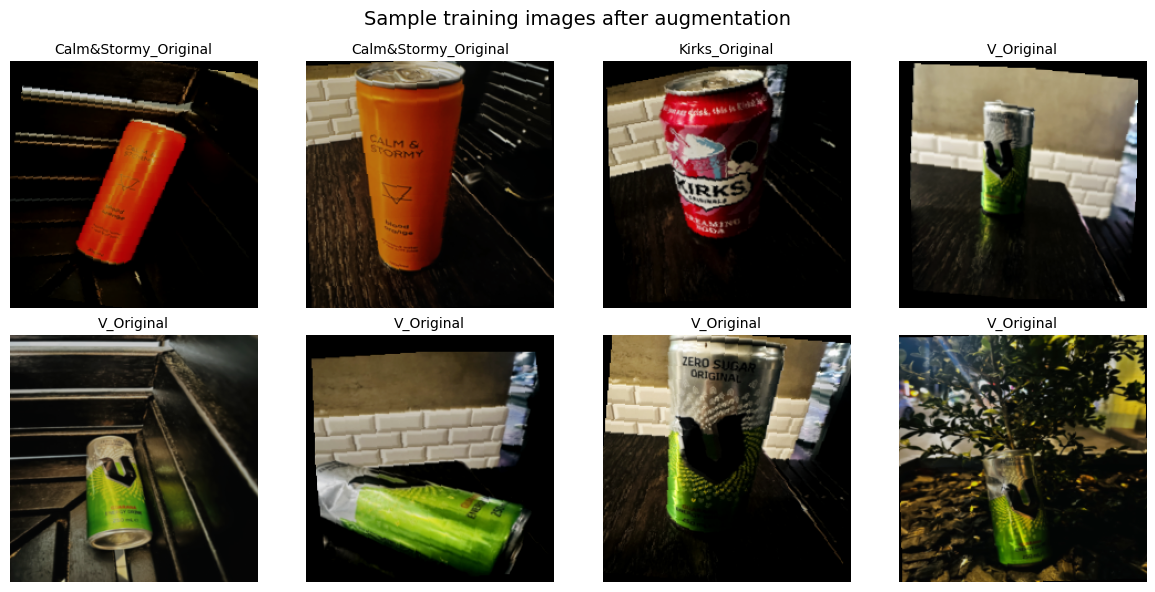

In [ ]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


sample_images, sample_labels, _ = next(iter(train_loader))
n_show = min(8, len(sample_images))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(len(axes)):
    axes[i].axis("off")
    if i < n_show:
        axes[i].imshow(denormalize(sample_images[i]).permute(1, 2, 0))
        axes[i].set_title(idx_to_class[int(sample_labels[i])], fontsize=10)

fig.suptitle("Sample training images after augmentation", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sample_training_images.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Pretrained CNN Model Selection

Two pretrained CNN architectures are evaluated:

1. **ResNet18**: A residual CNN that is widely used as a strong transfer-learning baseline. It is deeper than older CNNs such as AlexNet and uses skip connections to improve feature learning.
2. **MobileNetV3-Small**: A lightweight CNN designed for efficient deployment. This is relevant because the later project stage involves robot vision, where inference speed and resource usage matter.

For both models, ImageNet pretrained weights are loaded and the final classification layer is replaced with a four-class classifier for the beverage can classes.

In [ ]:
NUM_CLASSES = len(classes)
MODEL_NAMES = ["resnet18", "mobilenet_v3_small"]


def build_model(model_name: str, num_classes: int) -> nn.Module:
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        return model

    if model_name == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unsupported model: {model_name}")


for name in MODEL_NAMES:
    model = build_model(name, NUM_CLASSES)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {trainable_params:,} trainable parameters / {total_params:,} total parameters")

resnet18: 2,052 trainable parameters / 11,178,564 total parameters
mobilenet_v3_small: 4,100 trainable parameters / 1,521,956 total parameters


## 6. Training and Validation

Only the new classifier head is trained. This is a practical transfer-learning choice for a small custom dataset because the pretrained convolutional layers already provide useful visual features, while freezing most parameters reduces overfitting risk and keeps training efficient.

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_training:
                loss.backward()
                optimizer.step()

        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_seen += batch_size

    return {
        "loss": total_loss / total_seen,
        "accuracy": total_correct / total_seen,
    }


def train_model(model_name: str, epochs: int = 5):
    model = build_model(model_name, NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3,
        weight_decay=1e-4,
    )

    history = []
    best_val_acc = -1.0
    best_state = None
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = run_one_epoch(model, val_loader, criterion)

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{model_name} | epoch {epoch:02d}/{epochs} | "
            f"train acc {train_metrics['accuracy']:.3f} | "
            f"val acc {val_metrics['accuracy']:.3f} | "
            f"train loss {train_metrics['loss']:.3f} | "
            f"val loss {val_metrics['loss']:.3f}"
        )

    elapsed = time.time() - start_time
    if best_state is not None:
        model.load_state_dict(best_state)

    model_path = OUTPUT_DIR / f"{model_name}_best_classifier_head.pt"
    torch.save(model.state_dict(), model_path)

    print(f"{model_name} training completed in {elapsed:.1f} seconds")
    print(f"Best model saved to {model_path}")

    return model, pd.DataFrame(history)

In [ ]:
EPOCHS = 5

trained_models = {}
histories = []

for model_name in MODEL_NAMES:
    print("\n" + "=" * 72)
    print(f"Training {model_name}")
    print("=" * 72)
    model, history_df = train_model(model_name, epochs=EPOCHS)
    trained_models[model_name] = model
    histories.append(history_df)

history_df = pd.concat(histories, ignore_index=True)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
display(history_df)


Training resnet18
resnet18 | epoch 01/5 | train acc 0.350 | val acc 0.600 | train loss 1.432 | val loss 1.089
resnet18 | epoch 02/5 | train acc 0.504 | val acc 0.750 | train loss 1.197 | val loss 0.843
resnet18 | epoch 03/5 | train acc 0.752 | val acc 0.850 | train loss 0.919 | val loss 0.722
resnet18 | epoch 04/5 | train acc 0.863 | val acc 0.850 | train loss 0.730 | val loss 0.600
resnet18 | epoch 05/5 | train acc 0.829 | val acc 0.850 | train loss 0.636 | val loss 0.574
resnet18 training completed in 256.8 seconds
Best model saved to /content/drive/My Drive/Can detection/phase2_outputs/resnet18_best_classifier_head.pt

Training mobilenet_v3_small
mobilenet_v3_small | epoch 01/5 | train acc 0.368 | val acc 0.650 | train loss 1.321 | val loss 1.022
mobilenet_v3_small | epoch 02/5 | train acc 0.897 | val acc 0.900 | train loss 0.891 | val loss 0.655
mobilenet_v3_small | epoch 03/5 | train acc 0.915 | val acc 0.900 | train loss 0.636 | val loss 0.475
mobilenet_v3_small | epoch 04/5 | t

,model,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,resnet18,1,1.431548,0.350427,1.089138,0.60
1,resnet18,2,1.197289,0.504274,0.843455,0.75
2,resnet18,3,0.918933,0.752137,0.721717,0.85
3,resnet18,4,0.730472,0.863248,0.599820,0.85
4,resnet18,5,0.635916,0.829060,0.574298,0.85
5,mobilenet_v3_small,1,1.321366,0.367521,1.022312,0.65
6,mobilenet_v3_small,2,0.891272,0.897436,0.654981,0.90
7,mobilenet_v3_small,3,0.635857,0.914530,0.475066,0.90
8,mobilenet_v3_small,4,0.473894,0.948718,0.376813,0.90
9,mobilenet_v3_small,5,0.400910,0.974359,0.312510,0.90


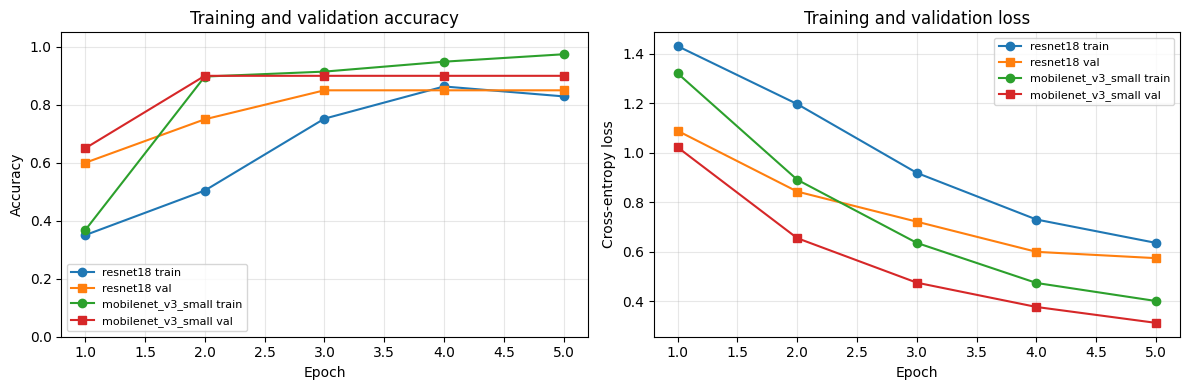

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name in MODEL_NAMES:
    model_history = history_df[history_df["model"] == model_name]
    axes[0].plot(model_history["epoch"], model_history["train_accuracy"], marker="o", label=f"{model_name} train")
    axes[0].plot(model_history["epoch"], model_history["val_accuracy"], marker="s", label=f"{model_name} val")
    axes[1].plot(model_history["epoch"], model_history["train_loss"], marker="o", label=f"{model_name} train")
    axes[1].plot(model_history["epoch"], model_history["val_loss"], marker="s", label=f"{model_name} val")

axes[0].set_title("Training and validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title("Training and validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-entropy loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Testing, Metrics, and Model Comparison

The final evaluation uses the held-out test set, which was not used for training or validation. Accuracy is reported together with precision, recall, F1-score, and confusion matrices.

In [ ]:
@torch.no_grad()
def predict_on_loader(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []
    all_paths = []

    for images, labels, paths in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
        predictions = probabilities.argmax(axis=1)

        all_true.extend(labels.numpy().tolist())
        all_pred.extend(predictions.tolist())
        all_prob.extend(probabilities.max(axis=1).tolist())
        all_paths.extend(paths)

    return pd.DataFrame(
        {
            "path": all_paths,
            "true_idx": all_true,
            "pred_idx": all_pred,
            "confidence": all_prob,
        }
    )


result_rows = []
prediction_frames = {}
report_dict = {}

for model_name, model in trained_models.items():
    pred_df = predict_on_loader(model, test_loader)
    pred_df["true_label"] = pred_df["true_idx"].map(idx_to_class)
    pred_df["pred_label"] = pred_df["pred_idx"].map(idx_to_class)
    pred_df["correct"] = pred_df["true_idx"] == pred_df["pred_idx"]
    prediction_frames[model_name] = pred_df

    accuracy = accuracy_score(pred_df["true_idx"], pred_df["pred_idx"])
    report = classification_report(
        pred_df["true_idx"],
        pred_df["pred_idx"],
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )
    report_dict[model_name] = report

    result_rows.append(
        {
            "model": model_name,
            "test_accuracy": accuracy,
            "macro_precision": report["macro avg"]["precision"],
            "macro_recall": report["macro avg"]["recall"],
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"],
            "test_images": len(pred_df),
            "misclassified": int((~pred_df["correct"]).sum()),
        }
    )

    pred_df.to_csv(OUTPUT_DIR / f"{model_name}_test_predictions.csv", index=False)

results_df = pd.DataFrame(result_rows).sort_values("test_accuracy", ascending=False)
results_df.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)

with open(OUTPUT_DIR / "classification_reports.json", "w", encoding="utf-8") as f:
    json.dump(report_dict, f, indent=2)

display(results_df)
print("Detailed metrics saved to:", OUTPUT_DIR)

,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,test_images,misclassified
1,mobilenet_v3_small,0.900000,0.924812,0.878125,0.889361,0.897068,60,6
0,resnet18,0.866667,0.858558,0.852083,0.853105,0.865707,60,8


Detailed metrics saved to: /content/drive/My Drive/Can detection/phase2_outputs


In [ ]:
for model_name, pred_df in prediction_frames.items():
    print("\n" + "=" * 72)
    print(f"Classification report: {model_name}")
    print("=" * 72)
    print(
        classification_report(
            pred_df["true_idx"],
            pred_df["pred_idx"],
            target_names=classes,
            zero_division=0,
        )
    )


Classification report: resnet18
                      precision    recall  f1-score   support

Calm&Stormy_Original       0.94      1.00      0.97        16
      Kirks_Original       0.94      0.83      0.88        18
       Solo_Original       0.78      0.70      0.74        10
          V_Original       0.78      0.88      0.82        16

            accuracy                           0.87        60
           macro avg       0.86      0.85      0.85        60
        weighted avg       0.87      0.87      0.87        60


Classification report: mobilenet_v3_small
                      precision    recall  f1-score   support

Calm&Stormy_Original       0.84      1.00      0.91        16
      Kirks_Original       0.86      1.00      0.92        18
       Solo_Original       1.00      0.70      0.82        10
          V_Original       1.00      0.81      0.90        16

            accuracy                           0.90        60
           macro avg       0.92      0.88      0.89

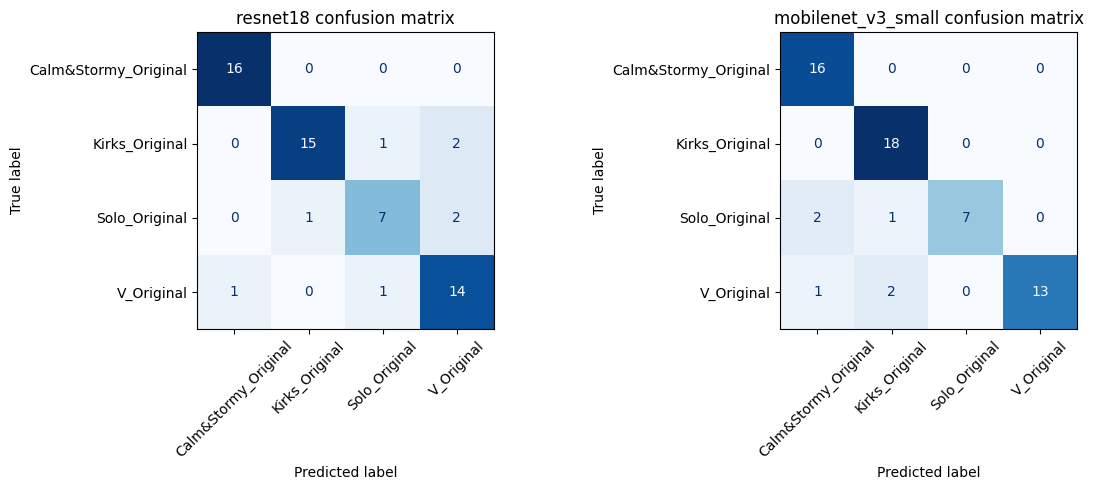

In [ ]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(6 * len(MODEL_NAMES), 5))
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    pred_df = prediction_frames[model_name]
    cm = confusion_matrix(pred_df["true_idx"], pred_df["pred_idx"], labels=list(range(NUM_CLASSES)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{model_name} confusion matrix")
    ax.tick_params(axis="x", labelrotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Misclassified Image Analysis

The following visualizations show test images where the predicted label does not match the true label. These examples are useful because fine-grained classification errors often happen when the can is photographed from the side, the label is partly hidden, the image has reflections, or the background becomes too visually dominant.

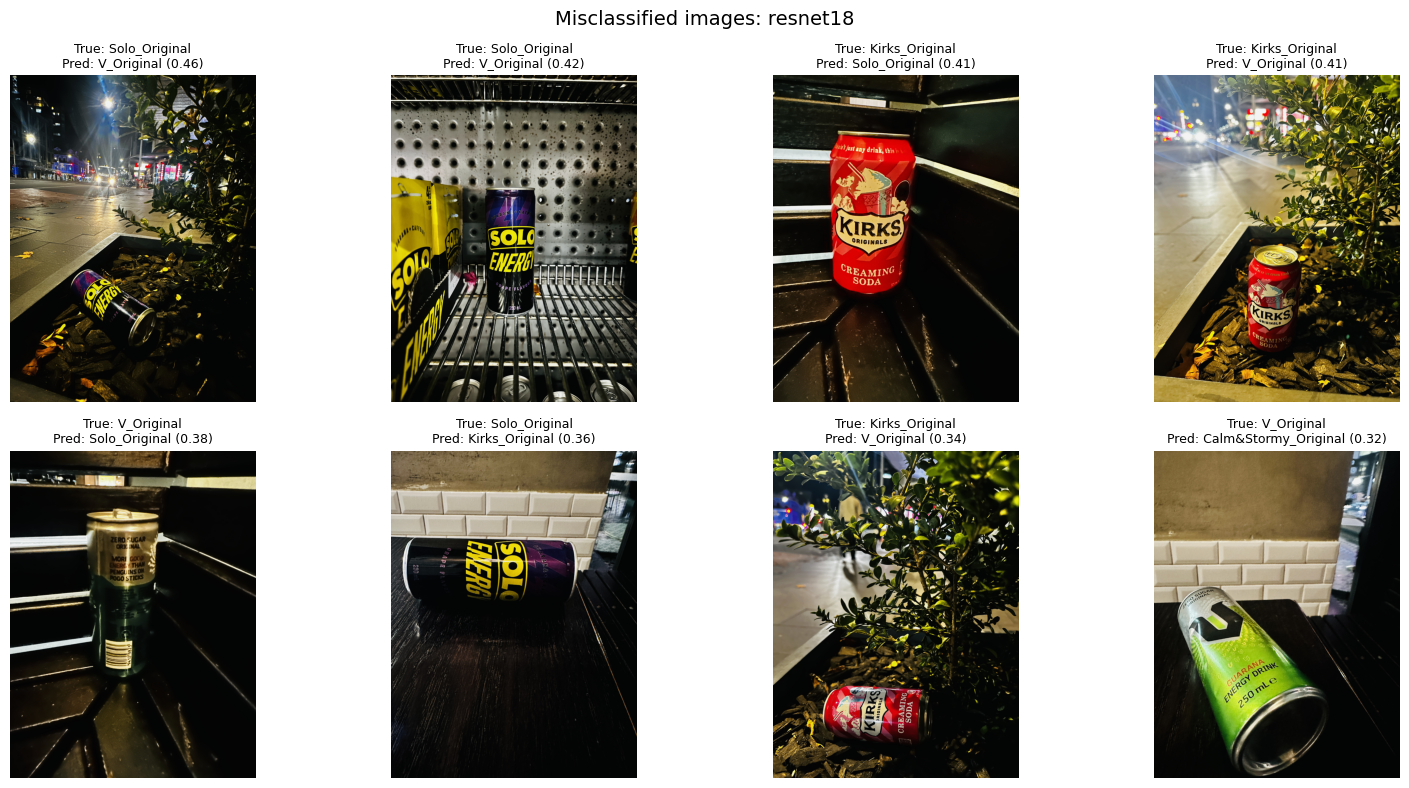

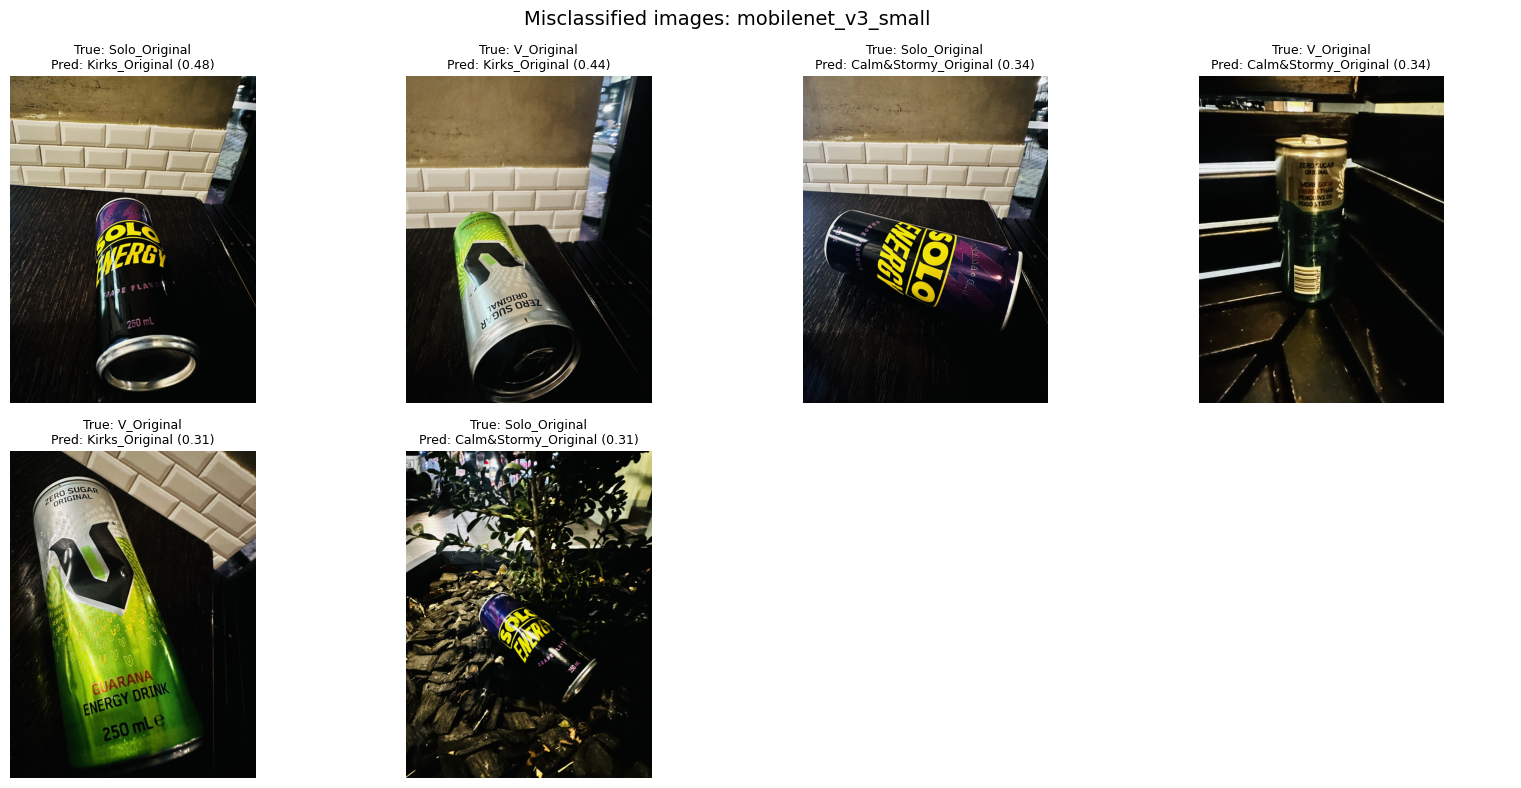

In [ ]:
def show_misclassified(model_name: str, max_images: int = 12):
    pred_df = prediction_frames[model_name]
    mistakes = pred_df[pred_df["correct"] == False].copy()

    if mistakes.empty:
        print(f"{model_name}: no misclassified test images in this split.")
        return

    mistakes = mistakes.sort_values("confidence", ascending=False).head(max_images)
    n = len(mistakes)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, mistakes.iterrows()):
        image = Image.open(row["path"]).convert("RGB")
        image = ImageOps.exif_transpose(image)
        ax.imshow(image)
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['pred_label']} ({row['confidence']:.2f})",
            fontsize=9,
        )
        ax.axis("off")

    fig.suptitle(f"Misclassified images: {model_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{model_name}_misclassified_images.png", dpi=160, bbox_inches="tight")
    plt.show()


for model_name in MODEL_NAMES:
    show_misclassified(model_name)

In [ ]:
all_error_rows = []
for model_name, pred_df in prediction_frames.items():
    mistakes = pred_df[pred_df["correct"] == False].copy()
    if not mistakes.empty:
        error_counts = (
            mistakes.groupby(["true_label", "pred_label"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
        error_counts.insert(0, "model", model_name)
        all_error_rows.append(error_counts)

if all_error_rows:
    error_summary = pd.concat(all_error_rows, ignore_index=True)
    error_summary.to_csv(OUTPUT_DIR / "misclassification_summary.csv", index=False)
    display(error_summary)
else:
    print("No misclassification pairs found for either model in this split.")

,model,true_label,pred_label,count
0,resnet18,Kirks_Original,V_Original,2
1,resnet18,Solo_Original,V_Original,2
2,resnet18,Kirks_Original,Solo_Original,1
3,resnet18,Solo_Original,Kirks_Original,1
4,resnet18,V_Original,Calm&Stormy_Original,1
5,resnet18,V_Original,Solo_Original,1
6,mobilenet_v3_small,Solo_Original,Calm&Stormy_Original,2
7,mobilenet_v3_small,V_Original,Kirks_Original,2
8,mobilenet_v3_small,Solo_Original,Kirks_Original,1
9,mobilenet_v3_small,V_Original,Calm&Stormy_Original,1


## 9. Discussion

The best-performing model was MobileNetV3-Small, achieving a test accuracy of 90.00% and a macro F1-score of 0.867. Compared with ResNet18, MobileNetV3-Small achieved an accuracy improvement of 3.33 percentage points, indicating that it provided better overall classification performance on the beverage can dataset.


I found several strenghts during the experiments:

- Transfer learning proved highly effective for this relatively small custom dataset. The pretrained ImageNet features already capture useful visual patterns such as edges, colours, shapes, and object structures, allowing the models to learn beverage can categories efficiently.
- ResNet18 provided a strong baseline performance, demonstrating stable feature extraction capabilities due to its residual learning architecture.
- MobileNetV3-Small achieved the best balance between accuracy and efficiency, making it particularly suitable for future robotic deployment where computational resources and inference speed are important considerations.


There were several limitations observed in the experiment:

- The dataset remains relatively small, particularly for the **Solo** class, which may limit the model's ability to generalise to unseen environments.
- Images collected during similar photography sessions may be visually correlated, potentially causing test performance to appear stronger than real-world performance.

